LAB SHEET 2 - ISHIKA AWASTHI | Roll no. 23 | CU24250188

In [ ]:
import cv2
import numpy as np
import os
from google.colab import files
from IPython.display import display
from PIL import Image

In [ ]:
uploaded = files.upload()

Saving pngtree-beautiful-garden-flowers-hd-background-wallpaper-vibrant-desktop-picture-image_15834668.jpg to pngtree-beautiful-garden-flowers-hd-background-wallpaper-vibrant-desktop-picture-image_15834668.jpg


In [ ]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_UNCHANGED)

if image is None:
    print("Could not load image.")
else:
    print("Image loaded successfully!")

Image loaded successfully!


In [ ]:
if len(image.shape) == 2:
    height, width = image.shape
    channels = 1
else:
    height, width, channels = image.shape

print("Filename     :", filename)
print("Dimensions   :", width, "x", height)
print("Channels     :", channels)
print("Data Type    :", image.dtype)
print("Array Shape  :", image.shape)

Filename     : pngtree-beautiful-garden-flowers-hd-background-wallpaper-vibrant-desktop-picture-image_15834668.jpg
Dimensions   : 1200 x 600
Channels     : 3
Data Type    : uint8
Array Shape  : (600, 1200, 3)


In [ ]:
file_size = os.path.getsize(filename)

print("File Size    :", file_size, "bytes")
print("File Size    :", round(file_size / 1024, 2), "KB")

File Size    : 298017 bytes
File Size    : 291.03 KB


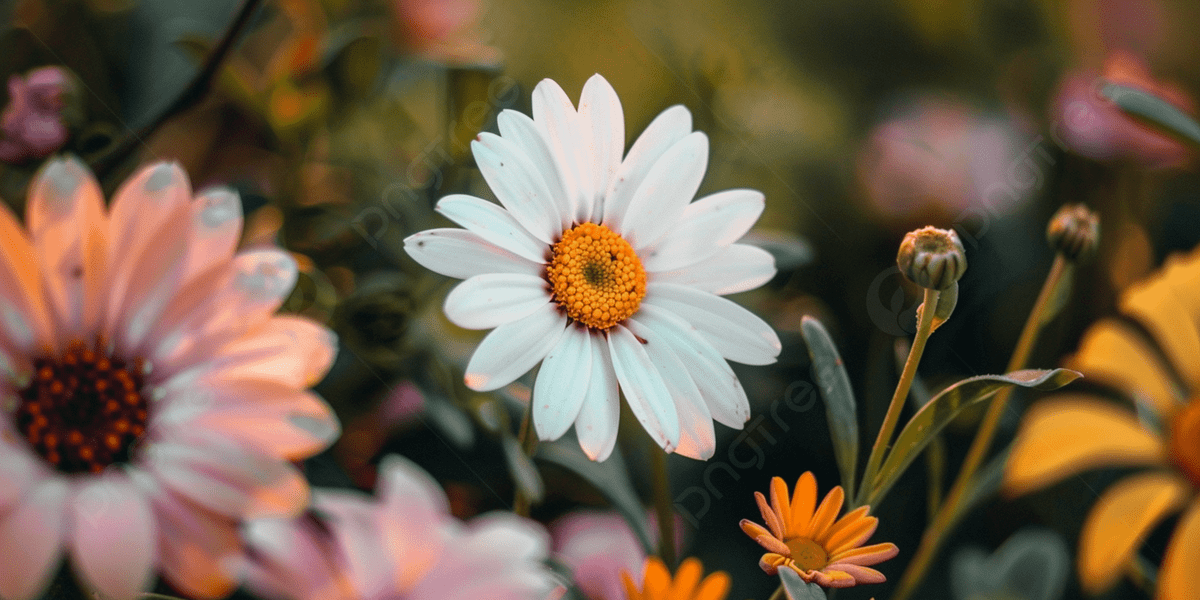

In [ ]:
if channels == 3:
    display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(display_image))
else:
    display(Image.fromarray(image))

TASK 2

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Selected image:", filename)

Saving ChatGPT Image Sep 14, 2026, 12_24_23 PM.png to ChatGPT Image Sep 14, 2026, 12_24_23 PM (2).png
Selected image: ChatGPT Image Sep 14, 2026, 12_24_23 PM (2).png


In [ ]:
image = cv2.imread(filename)

if image is None:
    print("Could not load image.")
else:
    print("Image loaded successfully!")
    print("Original shape:", image.shape)

Image loaded successfully!
Original shape: (1024, 1536, 3)


In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [ ]:
print("Grayscale shape:", gray.shape)

Grayscale shape: (1024, 1536)


In [ ]:
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

display(Image.fromarray(original_rgb))
display(Image.fromarray(gray))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
gray_3channel = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

In [ ]:
comparison = np.hstack((image, gray_3channel))

In [ ]:
output_filename = "colour_grayscale_comparison.jpg"

cv2.imwrite(output_filename, comparison)

print("Saved:", output_filename)

Saved: colour_grayscale_comparison.jpg


In [ ]:
comparison_rgb = cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB)

display(Image.fromarray(comparison_rgb))

Output hidden; open in https://colab.research.google.com to view.

TASK 3


In [ ]:
image = cv2.imread(filename)

if image is None:
    print("Could not load image.")

else:

    print("Image loaded successfully!")
    print("Image shape:", image.shape)

    # ---------------------------------------
    # 3. Save in three formats
    # ---------------------------------------

    jpg_file = "converted_image.jpg"
    png_file = "converted_image.png"
    bmp_file = "converted_image.bmp"

    cv2.imwrite(jpg_file, image)
    cv2.imwrite(png_file, image)
    cv2.imwrite(bmp_file, image)



Image loaded successfully!
Image shape: (1024, 1536, 3)


### 4. Calculate file sizes

In [ ]:
jpg_size = os.path.getsize(jpg_file)
png_size = os.path.getsize(png_file)
bmp_size = os.path.getsize(bmp_file)

jpg_kb = jpg_size / 1024
png_kb = png_size / 1024
bmp_kb = bmp_size / 1024

### 5. Display comparison

In [ ]:
print("\n==============================")
print("     FILE SIZE COMPARISON")
print("==============================")

print(f"JPG : {jpg_kb:.2f} KB")
print(f"PNG : {png_kb:.2f} KB")
print(f"BMP : {bmp_kb:.2f} KB")


     FILE SIZE COMPARISON
JPG : 806.67 KB
PNG : 3135.80 KB
BMP : 4608.05 KB


### 6. Find smallest

In [ ]:
sizes = {
    "JPG": jpg_kb,
    "PNG": png_kb,
    "BMP": bmp_kb
}

smallest = min(sizes, key=sizes.get)

print("\nSmallest format:", smallest)


Smallest format: JPG


## Photo Negative Generator

In [ ]:
# Calculate the photo negative (complement) of the image
# For an 8-bit image, the negative is 255 - pixel_value
negative_image = 255 - image

print("Negative image shape:", negative_image.shape)

Negative image shape: (1024, 1536, 3)


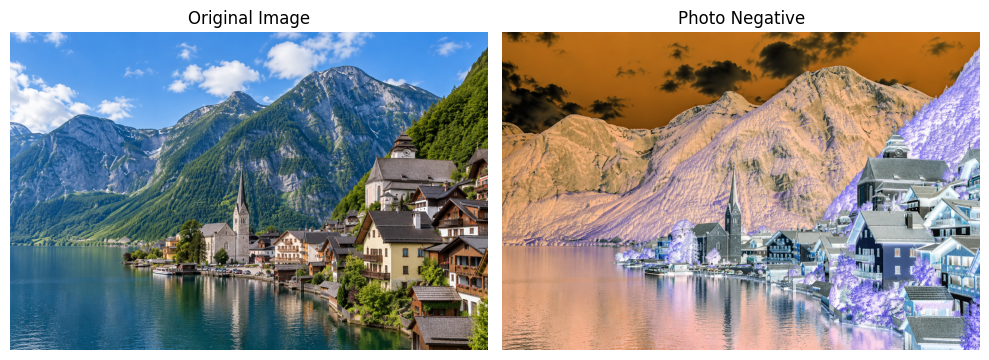

In [ ]:
import matplotlib.pyplot as plt

# Convert images from BGR to RGB for proper display
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
negative_rgb = cv2.cvtColor(negative_image, cv2.COLOR_BGR2RGB)

# Display the original and negative images side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_rgb)
plt.title('Photo Negative')
plt.axis('off')

plt.tight_layout()
plt.show()

## Batch Image Resizer

This section will demonstrate how to resize multiple images in a batch, preserving their aspect ratio.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
input_folder = '/content/drive/MyDrive/input_images' # Change this to your input folder path
output_folder = '/content/drive/MyDrive/resized_images' # Change this to your output folder path

# Create input and output folders if they don't exist
os.makedirs(input_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

# --- Placeholder image generation (for demonstration if no images are provided) ---
# This part ensures the script can run even without pre-uploaded images.
if not any(fname.endswith(('.jpg', '.png', '.jpeg')) for fname in os.listdir(input_folder)):
    print(f"No images found in {input_folder}. Generating placeholder images...")
    for i in range(3):
        dummy_image = np.random.randint(0, 256, (np.random.randint(200, 500), np.random.randint(300, 600), 3), dtype=np.uint8)
        cv2.imwrite(os.path.join(input_folder, f'dummy_image_{i+1}.png'), dummy_image)
    print("Placeholder images generated.")
else:
    print(f"Using images from {input_folder}.")


Using images from /content/drive/MyDrive/input_images.


Now, let's define the resizing parameters and process the images.

In [ ]:
target_width = 300  # Set your desired width. If `target_height` is also set, it will be ignored.
# target_height = 200 # You can set target height instead of width if preferred, but not both.

print(f"Resizing images in '{input_folder}' to a width of {target_width} pixels (preserving aspect ratio) and saving to '{output_folder}'.")

for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(input_folder, filename)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Warning: Could not read image {filename}. Skipping.")
            continue

        # Get original dimensions
        original_height, original_width = img.shape[0], img.shape[1]

        # Calculate new dimensions while preserving aspect ratio
        if 'target_width' in locals() and target_width is not None:
            ratio = target_width / original_width
            new_width = target_width
            new_height = int(original_height * ratio)
        elif 'target_height' in locals() and target_height is not None:
            ratio = target_height / original_height
            new_height = target_height
            new_width = int(original_width * ratio)
        else:
            print(f"Error: Either target_width or target_height must be set for {filename}. Skipping.")
            continue

        # Resize the image
        resized_img = cv2.resize(img, (new_width, new_height), interpolation=cv2.INTER_AREA)

        # Save the resized image to the output folder
        output_filename = f"resized_{filename}"
        output_path = os.path.join(output_folder, output_filename)
        cv2.imwrite(output_path, resized_img)

        print(f"Resized '{filename}' from {original_width}x{original_height} to {new_width}x{new_height} and saved as '{output_filename}'")

print("\nBatch resizing complete!")


Resizing images in '/content/drive/MyDrive/input_images' to a width of 300 pixels (preserving aspect ratio) and saving to '/content/drive/MyDrive/resized_images'.
Resized 'dummy_image_1.png' from 528x492 to 300x279 and saved as 'resized_dummy_image_1.png'
Resized 'dummy_image_2.png' from 309x225 to 300x218 and saved as 'resized_dummy_image_2.png'
Resized 'dummy_image_3.png' from 402x295 to 300x220 and saved as 'resized_dummy_image_3.png'
Resized 'IMAGE.jpg' from 841x558 to 300x199 and saved as 'resized_IMAGE.jpg'

Batch resizing complete!


## Image Cropping (Region of Interest - ROI)

In [ ]:
# Assuming 'image' variable already holds the loaded image from previous steps
# If not, you might need to load an image first, for example:
# image = cv2.imread(filename)

if 'image' not in locals():
    print("No image loaded. Please run the image loading cells first.")
else:
    print("Using the currently loaded image for cropping.")

Using the currently loaded image for cropping.


 Define the Region of Interest (ROI)


In [ ]:
# Define ROI coordinates (x, y, width, height)
# Example: Cropping a 100x100 square starting at (50, 50)
x = 50
y = 50
w = 200 # width
h = 150 # height

# Ensure ROI is within image boundaries
img_height, img_width = image.shape[0], image.shape[1]

if (x + w) > img_width or (y + h) > img_height:
    print(f"Warning: The defined ROI ({x},{y},{w},{h}) extends beyond image boundaries ({img_width},{img_height}). Adjusting ROI.")
    w = min(w, img_width - x)
    h = min(h, img_height - y)
    print(f"Adjusted ROI: x={x}, y={y}, w={w}, h={h}")

# Crop the image
cropped_image = image[y:y+h, x:x+w]

print(f"Original image shape: {image.shape}")
print(f"Cropped image shape: {cropped_image.shape}")

Original image shape: (1024, 1536, 3)
Cropped image shape: (150, 200, 3)


2. Display Original Image with ROI and the Cropped Image

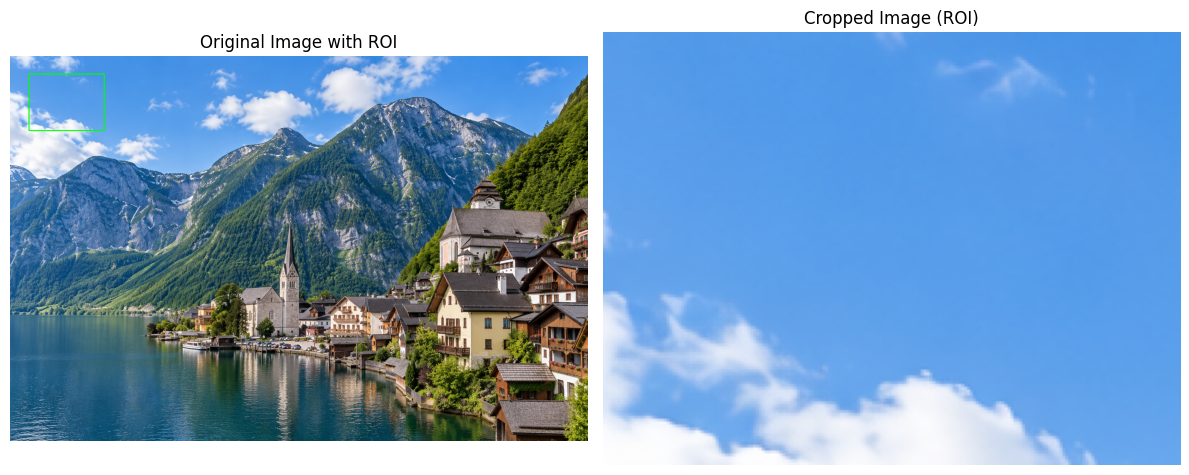

In [ ]:
import matplotlib.pyplot as plt

# Create a copy of the original image to draw the rectangle on
image_with_roi = image.copy()

# Draw a rectangle around the ROI on the copied image (Green color, thickness 2)
cv2.rectangle(image_with_roi, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Convert images to RGB for displaying with Matplotlib
image_with_roi_rgb = cv2.cvtColor(image_with_roi, cv2.COLOR_BGR2RGB)
cropped_image_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

# Display both images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_with_roi_rgb)
plt.title('Original Image with ROI')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped_image_rgb)
plt.title('Cropped Image (ROI)')
plt.axis('off')

plt.tight_layout()
plt.show()

3. Save the Cropped Image

In [ ]:
output_cropped_filename = "cropped_image.jpg"
cv2.imwrite(output_cropped_filename, cropped_image)
print(f"Cropped image saved as: {output_cropped_filename}")

# You can also download the cropped image
files.download(output_cropped_filename)

Cropped image saved as: cropped_image.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## RGB Channel Split, Reconstruction, and Verification

In [ ]:
if 'image' not in locals():
    print("No image loaded. Please run the image loading cells first.")
else:
    print("Using the currently loaded image for RGB channel operations.")

Using the currently loaded image for RGB channel operations.


### 1. Split the image into Red, Green, and Blue channels

In [ ]:
# Split the image into its B, G, R channels (OpenCV uses BGR by default)
b, g, r = cv2.split(image)

print(f"Blue channel shape: {b.shape}")
print(f"Green channel shape: {g.shape}")
print(f"Red channel shape: {r.shape}")

Blue channel shape: (1024, 1536)
Green channel shape: (1024, 1536)
Red channel shape: (1024, 1536)


### 2. Display individual channels

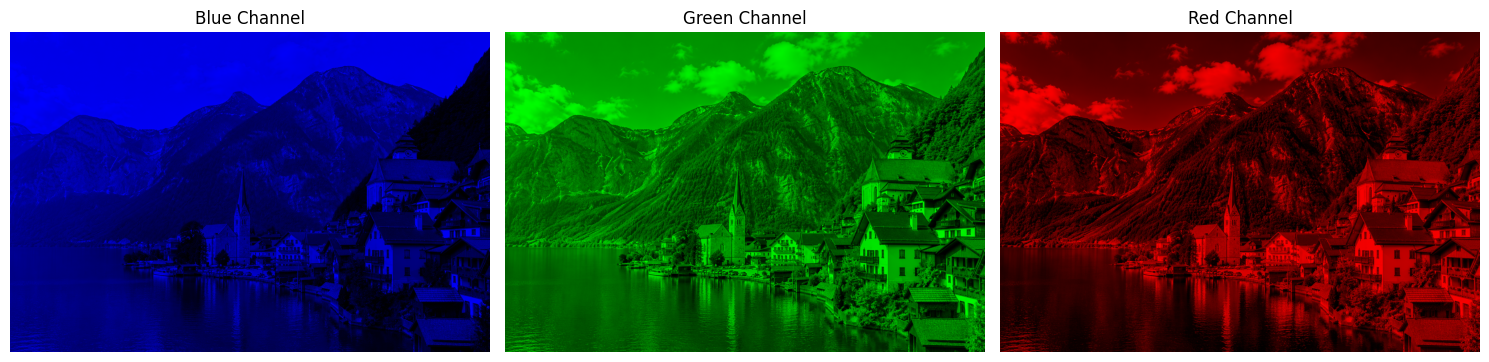

In [ ]:
import matplotlib.pyplot as plt

# Create empty arrays for other channels to display individual channels as grayscale
zeros = np.zeros(image.shape[:2], dtype="uint8")

# Merge channels to display individual B, G, R as color images (optional, but visually clearer)
blue_channel_img = cv2.merge([b, zeros, zeros])
green_channel_img = cv2.merge([zeros, g, zeros])
red_channel_img = cv2.merge([zeros, zeros, r])

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(blue_channel_img, cv2.COLOR_BGR2RGB))
plt.title('Blue Channel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(green_channel_img, cv2.COLOR_BGR2RGB))
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(red_channel_img, cv2.COLOR_BGR2RGB))
plt.title('Red Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Reconstruct the image from channels

Reconstructed image shape: (1024, 1536, 3)


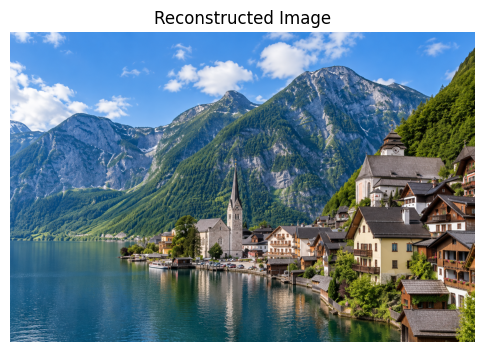

In [ ]:
# Merge the individual channels back to form a BGR image
reconstructed_image = cv2.merge([b, g, r])

print(f"Reconstructed image shape: {reconstructed_image.shape}")

# Display the reconstructed image
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(reconstructed_image, cv2.COLOR_BGR2RGB))
plt.title('Reconstructed Image')
plt.axis('off')
plt.show()

### 4. Verify pixel-level accuracy

In [ ]:
# Compare the original image with the reconstructed image
# They should be identical if the process is accurate

# Check if all pixels are exactly the same
if np.array_equal(image, reconstructed_image):
    print("Pixel-level accuracy verified: Original and reconstructed images are identical.")
else:
    print("Warning: Original and reconstructed images are NOT identical. There might be an issue.")

# Optionally, calculate the difference (should be all zeros for identical images)
difference = cv2.subtract(image, reconstructed_image)
b, g, r = cv2.split(difference)

if cv2.countNonZero(b) == 0 and cv2.countNonZero(g) == 0 and cv2.countNonZero(r) == 0:
    print("Difference image is all zeros, confirming pixel-level accuracy.")
else:
    print("Difference image contains non-zero pixels.")

# You can display the difference image to visualize any discrepancies
# plt.figure(figsize=(6,6))
# plt.imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
# plt.title('Difference Image (should be black)')
# plt.axis('off')
# plt.show()

Pixel-level accuracy verified: Original and reconstructed images are identical.
Difference image is all zeros, confirming pixel-level accuracy.


## Image Watermarking Utility

This section demonstrates how to overlay text as a watermark on an image.

In [ ]:
# Assuming 'image' variable already holds the loaded image from previous steps
# If not, you might need to load an image first.

if 'image' not in locals():
    print("No image loaded. Please run the image loading cells first.")
else:
    print("Using the currently loaded image for watermarking.")

Using the currently loaded image for watermarking.


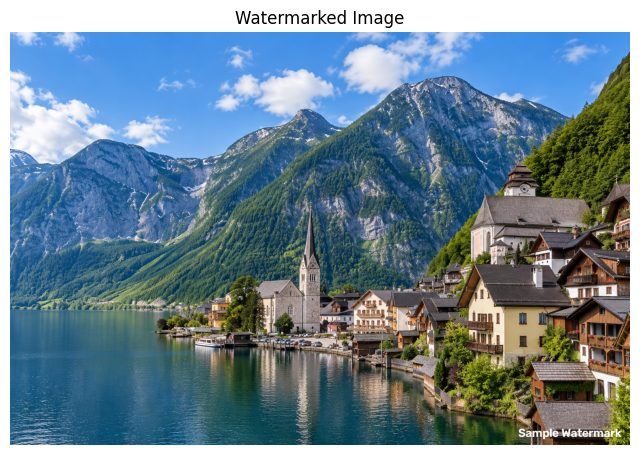

In [ ]:
# Make a copy of the image to draw the watermark on
watermarked_image = image.copy()

# --- Define Watermark Properties ---
text = "Sample Watermark"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_thickness = 2
text_color = (255, 255, 255) # White color in BGR

# Get text size to position it
(text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

# Position the text (e.g., bottom-right corner with some padding)
# image.shape[1] is width, image.shape[0] is height
padding = 20
x_pos = watermarked_image.shape[1] - text_width - padding
y_pos = watermarked_image.shape[0] - padding

# Add the watermark text to the image
cv2.putText(watermarked_image, text, (x_pos, y_pos), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

# --- Display the watermarked image ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(watermarked_image, cv2.COLOR_BGR2RGB))
plt.title('Watermarked Image')
plt.axis('off')
plt.show()

In [ ]:
# --- Save the watermarked image ---
output_watermarked_filename = "watermarked_image.jpg"
cv2.imwrite(output_watermarked_filename, watermarked_image)
print(f"Watermarked image saved as: {output_watermarked_filename}")

# You can also download the watermarked image
from google.colab import files
files.download(output_watermarked_filename)